# import libaries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import joblib

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
np.random.seed(42)

rows = 1000

df = pd.DataFrame({
    "Customer_ID": np.arange(1, rows + 1),
    "Age": np.random.randint(18, 70, rows),
    "Gender": np.random.choice(["Male", "Female"], rows),
    "Tenure": np.random.randint(1, 11, rows),
    "Monthly_Charges": np.random.randint(500, 5000, rows),
    "Total_Charges": np.random.randint(10000, 300000, rows),
    "Contract": np.random.choice(
        ["Month-to-Month", "One Year", "Two Year"],
        rows
    ),
    "Internet_Service": np.random.choice(
        ["Fiber", "DSL", "None"],
        rows
    ),
    "Payment_Method": np.random.choice(
        ["Credit Card",
         "Debit Card",
         "UPI",
         "Cash"],
        rows),
    "Churn": np.random.choice(
        ["Yes", "No"],
        rows)
})

df.head()

,Customer_ID,Age,Gender,Tenure,Monthly_Charges,Total_Charges,Contract,Internet_Service,Payment_Method,Churn
0,1,56,Male,1,3313,73811,Two Year,None,Cash,No
1,2,69,Male,2,3083,192385,Two Year,None,UPI,No
2,3,46,Male,8,661,73232,Month-to-Month,DSL,Debit Card,No
3,4,32,Female,3,1093,287561,Month-to-Month,Fiber,Debit Card,Yes
4,5,60,Male,10,3759,165801,Two Year,None,UPI,No


# save dataset

In [3]:
df.to_csv("data/customer_churn.csv", index=False)

print("Dataset Saved Successfully!")

Dataset Saved Successfully!


In [4]:
df = pd.read_csv("data/customer_churn.csv")

df.head()

,Customer_ID,Age,Gender,Tenure,Monthly_Charges,Total_Charges,Contract,Internet_Service,Payment_Method,Churn
0,1,56,Male,1,3313,73811,Two Year,NaN,Cash,No
1,2,69,Male,2,3083,192385,Two Year,NaN,UPI,No
2,3,46,Male,8,661,73232,Month-to-Month,DSL,Debit Card,No
3,4,32,Female,3,1093,287561,Month-to-Month,Fiber,Debit Card,Yes
4,5,60,Male,10,3759,165801,Two Year,NaN,UPI,No


In [5]:
print("Shape :", df.shape)

print("\nColumns :")
print(df.columns)

print("\nInformation :")
df.info()

Shape : (1000, 10)

Columns :
Index(['Customer_ID', 'Age', 'Gender', 'Tenure', 'Monthly_Charges',
       'Total_Charges', 'Contract', 'Internet_Service', 'Payment_Method',
       'Churn'],
      dtype='str')

Information :
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Customer_ID       1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Gender            1000 non-null   str  
 3   Tenure            1000 non-null   int64
 4   Monthly_Charges   1000 non-null   int64
 5   Total_Charges     1000 non-null   int64
 6   Contract          1000 non-null   str  
 7   Internet_Service  690 non-null    str  
 8   Payment_Method    1000 non-null   str  
 9   Churn             1000 non-null   str  
dtypes: int64(5), str(5)
memory usage: 78.3 KB


In [6]:
print(df.isnull().sum())

Customer_ID           0
Age                   0
Gender                0
Tenure                0
Monthly_Charges       0
Total_Charges         0
Contract              0
Internet_Service    310
Payment_Method        0
Churn                 0
dtype: int64


# encode categorical columns

In [7]:
encoder = LabelEncoder()

df["Gender"] = encoder.fit_transform(df["Gender"])
df["Contract"] = encoder.fit_transform(df["Contract"])
df["Internet_Service"] = encoder.fit_transform(df["Internet_Service"])
df["Payment_Method"] = encoder.fit_transform(df["Payment_Method"])
df["Churn"] = encoder.fit_transform(df["Churn"])

df.head()

,Customer_ID,Age,Gender,Tenure,Monthly_Charges,Total_Charges,Contract,Internet_Service,Payment_Method,Churn
0,1,56,1,1,3313,73811,2,2,0,0
1,2,69,1,2,3083,192385,2,2,3,0
2,3,46,1,8,661,73232,0,0,2,0
3,4,32,0,3,1093,287561,0,1,2,1
4,5,60,1,10,3759,165801,2,2,3,0


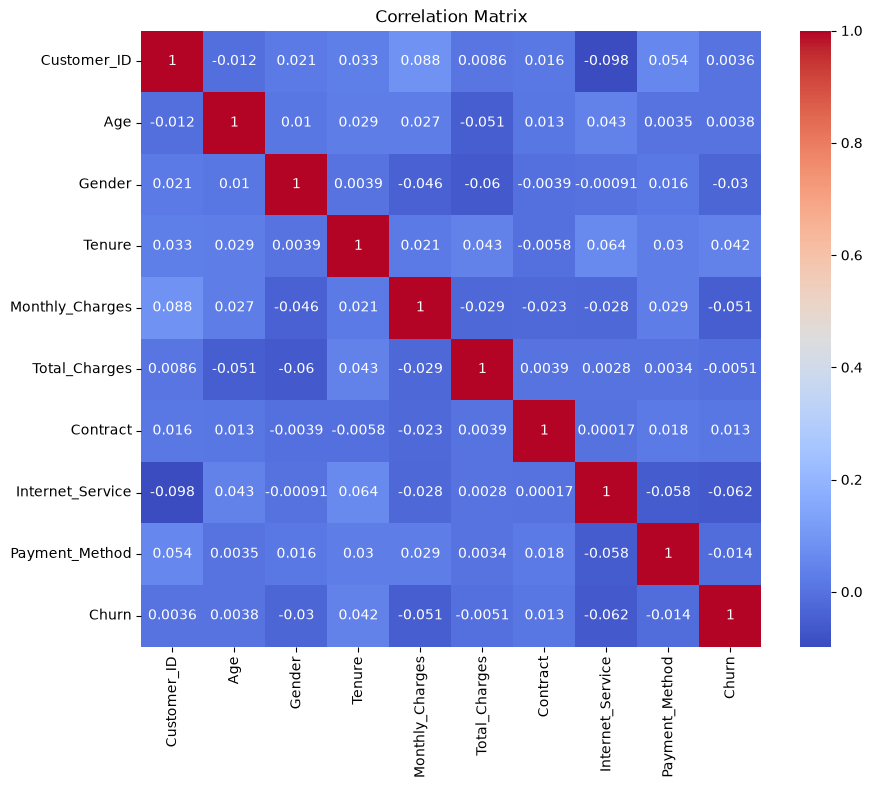

In [8]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [9]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print(X.head())
print("\nTarget:")
print(y.head())

   Customer_ID  Age  Gender  Tenure  Monthly_Charges  Total_Charges  Contract  \
0            1   56       1       1             3313          73811         2   
1            2   69       1       2             3083         192385         2   
2            3   46       1       8              661          73232         0   
3            4   32       0       3             1093         287561         0   
4            5   60       1      10             3759         165801         2   

   Internet_Service  Payment_Method  
0                 2               0  
1                 2               3  
2                 0               2  
3                 1               2  
4                 2               3  

Target:
0    0
1    0
2    0
3    1
4    0
Name: Churn, dtype: int64


# tarin test split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (800, 9)
Testing Data : (200, 9)


In [11]:
model = LogisticRegression(max_iter=1000)


In [12]:
model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


c:\Users\vishn\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[0 0 1 1 0 0 1 1 1 1]


In [14]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.52


# confusion matrix

[[54 45]
 [51 50]]


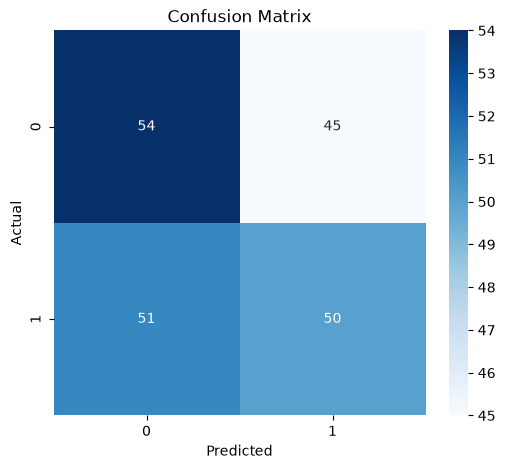

In [15]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [16]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.51      0.55      0.53        99
           1       0.53      0.50      0.51       101

    accuracy                           0.52       200
   macro avg       0.52      0.52      0.52       200
weighted avg       0.52      0.52      0.52       200



In [17]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/customer_churn_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [18]:
sample = X.iloc[[0]]

prediction = model.predict(sample)

print("Prediction:", prediction)

if prediction[0] == 1:
    print("Customer Will Churn")
else:
    print("Customer Will Not Churn")

Prediction: [0]
Customer Will Not Churn


In [19]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,0,0
1,0,0
2,1,1
3,1,1
4,0,0
5,1,0
6,0,1
7,0,1
8,1,1
9,1,1


In [20]:
print("="*50)
print(" CUSTOMER CHURN PREDICTION PROJECT COMPLETED ")
print("="*50)

print("Model Accuracy:", accuracy)

print("Model File: models/customer_churn_model.pkl")

 CUSTOMER CHURN PREDICTION PROJECT COMPLETED 
Model Accuracy: 0.52
Model File: models/customer_churn_model.pkl
